In [1]:
import numpy as np
import scipy as sp
import scipy.sparse, scipy.io, scipy.optimize
from scipy.special import expit

import matplotlib.pyplot as plt
import matplotlib as mpl
import time
%matplotlib inline

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a', # Color blind color cycle
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=CB_color_cycle) 

clip_01 = lambda M : np.clip(M, a_min=0, a_max=1)

from DataPreprocess import *

In [2]:
# adj = read_cahepph(ca_hepph_path='./data/CA-HepPh.txt')
# adj = read_cora(content_path="./data/cora/cora.content", cites_path="./data/cora/cora.cites")
# adj = read_cag_fb_wiki(ca_grqc_path="./data/CA-GrQc.txt")
adj = read_pubmed(folder_path="./data/Pubmed/data/")

Nodes = 19717
Mean degree = 4.496170817061419


In [3]:
def lpca_loss(factors, adj_s, rank): # adj_s = shifted adj with -1's and +1's
    n_row, n_col = adj_s.shape
    U = factors[:n_row*rank].reshape(n_row, rank)
    V = factors[n_row*rank:].reshape(rank, n_col)
    logits = U @ V
    prob_wrong = expit(-logits * adj_s)
    loss = (np.logaddexp(0,-logits*adj_s)).sum()# / n_element    
    U_grad = -(prob_wrong * adj_s) @ V.T# / n_element
    V_grad = -U.T @ (prob_wrong * adj_s)# / n_element
    print(loss)
    return loss, np.concatenate((U_grad.flatten(), V_grad.flatten()))

save_interval = 100 # the number of iterations after which to save the embeddings

def callback_recm(x_i): # prints the loss and periodically saves the factors
    global iter_num
    iter_num += 1
    if iter_num % save_interval == 0:
        global factors, n_row, n_col, rank
        factors = x_i
        U = factors[:n_row*rank].reshape(n_row, rank)
        V = factors[n_row*rank:].reshape(rank, n_col)
        frob_error_norm = np.linalg.norm(clip_01(U@V) - adj) / sp.sparse.linalg.norm(adj)
        print(iter_num, "Frob_error_norm: ", frob_error_norm)
        
# generate a rank k TSVD factorization of a small sparse matrix adj
def factor_TSVD(adj, k):
    w, v = np.linalg.eigh(np.array(adj.todense()))
    order = np.argsort(np.abs(w))[::-1]
    w = w[order[:k]]
    v = v[:,order[:k]]
    U_tsvd, V_tsvd = v * np.sqrt(np.abs(w))[None,:], (np.sign(w)*np.sqrt(np.abs(w)))[:,None] * v.T
    return U_tsvd, V_tsvd

# compute number of triangles in the subgraph induced by the first i nodes
def get_num_tri(i):
    global adj_recon_sort
    sub_adj = adj_recon_sort[:i+1,:i+1]
    num_tri = (1. * sub_adj @ sub_adj @ sub_adj).diagonal().sum() / 6
    return num_tri

In [4]:
def lpca_fit(adj, rank_value, maxiter=2000):
    global iter_num, factors, n_row, n_col, rank, frob_error_norm
    rank = rank_value
    n_row, n_col = adj.shape
    factors = -1+2*np.random.random(size=(np.sum(adj.shape)*rank)) # initalize uniformly on [-1,+1]
    iter_num = 0
    U = factors[:n_row*rank].reshape(n_row, rank)
    V = factors[n_row*rank:].reshape(rank, n_col)
    
    res = scipy.optimize.minimize(lpca_loss, x0=factors, 
                              args=(-1 + 2*np.array(adj.todense()), rank), jac=True, method='L-BFGS-B', 
                              callback=callback_recm, 
                              options={'maxiter':maxiter}
                             )
    factors = res.x
    U = res.x[:n_row*rank].reshape(n_row, rank)
    V = res.x[n_row*rank:].reshape(rank, n_col)
    frob_error_norm = np.linalg.norm(1.*(U @ V > 0) - adj) / sp.sparse.linalg.norm(adj)
    print("LPCA Frob norm error: ", frob_error_norm)
    return U, V

def tsvd_fit(adj, rank):
    U_tsvd, V_tsvd = factor_TSVD(adj, rank)
    frob_error_norm = np.linalg.norm(clip_01(U_tsvd@V_tsvd) - adj) / sp.sparse.linalg.norm(adj)
    print("TSVD Frob norm error: ", frob_error_norm)
    return U_tsvd, V_tsvd

In [5]:
# U_lpca_16, V_lpca_16 = lpca_fit(adj, rank_value=16, maxiter=2000)
U_lpca_32 = np.load('./matrices/Pubmed/U_lpca_rank32.npy')
V_lpca_32 = np.load('./matrices/Pubmed/V_lpca_rank32.npy')

U_tsvd_32, V_tsvd_32 = tsvd_fit(adj, rank=32)
U_tsvd_128, V_tsvd_128 = tsvd_fit(adj, rank=128)

TSVD Frob norm error:  0.9576278903449156
TSVD Frob norm error:  0.9027421421057118


In [6]:
def degree_sequence(U, V, method="lpca", skip_int=1):
    if method == "lpca":
        logits = U @ V
        P = expit(logits)
    elif method == "tsvd":
        P = clip_01(U @ V)
    deg = np.asarray(P.sum(axis=1)).ravel()
    deg_sorted = np.sort(deg)[::skip_int]
    return deg_sorted

def degree_sequence_true(adj, skip_int=1):
    deg = np.asarray(adj.sum(axis=1)).ravel()
    return np.sort(deg)[::skip_int]

Text(0.5, 1.0, 'Pubmed')

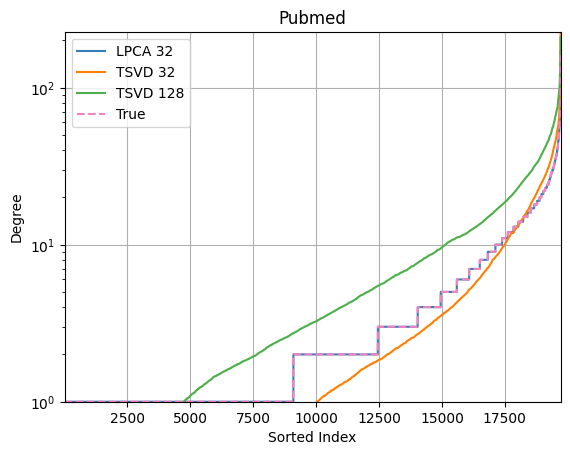

In [11]:
skip_int = 1

# deg_lpca_16_sorted = degree_sequence(U_lpca_16,  V_lpca_16,  method="lpca", skip_int=skip_int)
# deg_tsvd_16_sorted = degree_sequence(U_tsvd_16,  V_tsvd_16,  method="tsvd", skip_int=skip_int)
deg_lpca_32_sorted = degree_sequence(U_lpca_32,  V_lpca_32,  method="lpca", skip_int=skip_int)
deg_tsvd_32_sorted = degree_sequence(U_tsvd_32,  V_tsvd_32,  method="tsvd", skip_int=skip_int)
deg_tsvd_128_sorted = degree_sequence(U_tsvd_128, V_tsvd_128, method="tsvd", skip_int=skip_int)
deg_true_sorted = degree_sequence_true(adj, skip_int)

x = np.arange(1, len(deg_true_sorted) + 1)

fig, ax = plt.subplots()

# ax.semilogy(x, deg_lpca_16_sorted, label='LPCA 16')
# ax.semilogy(x, deg_tsvd_16_sorted, label='TSVD 16')
ax.semilogy(x, deg_lpca_32_sorted, label='LPCA 32')
ax.semilogy(x, deg_tsvd_32_sorted, label='TSVD 32')
ax.semilogy(x, deg_tsvd_128_sorted, label='TSVD 128')
ax.semilogy(x, deg_true_sorted, '--', label='True')

ax.autoscale(enable=True, axis='x', tight=True)
ax.autoscale(enable=True, axis='y', tight=True)

ax.set_ylim(1,)
# ax.set_xlim(-200, 6000)

ax.set_xlabel("Sorted Index")
ax.set_ylabel("Degree")
ax.grid()
ax.legend()
ax.set_title("Pubmed")